# Julian DEQUATRE

# Reinforcement Learning Individual Assignment
## Text Flappy Bird: Monte Carlo vs Sarsa(λ)

**Author:** Julian  
**Date:**  10/04/2026  

This notebook implements and compares two tabular reinforcement learning agents on the `TextFlappyBird-v0` environment:
- **Agent 1:** First-Visit Monte Carlo with ε-greedy policy
- **Agent 2:** Sarsa(λ) with eligibility traces (Section 12.7, Sutton & Barto)

---

## 0. Imports & Setup

In [1]:
import gymnasium as gym
import text_flappy_bird_gym  # registers TextFlappyBird-v0

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
from collections import defaultdict
from tqdm.auto import tqdm
import warnings
import random

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print(' All imports successful.')

 All imports successful.


## 1. Environment Exploration

`TextFlappyBird-v0` returns as observation the **(x, y) distance** of the player to the centre of the gap of the closest upcoming pipe.  
- **x** ∈ [0, width − 1] — horizontal distance to the pipe  
- **y** ∈ [−(height−1), +(height−1)] — vertical distance (negative = player is above gap centre)  
- **Actions:** 0 = do nothing (idle), 1 = flap  
- **Reward:** +1 for every step the player stays alive

In [2]:
# ── Default configuration (used for training) ─────────────────────────────
ENV_CONFIG = dict(height=15, width=20, pipe_gap=4)

env = gym.make('TextFlappyBird-v0', max_episode_steps=2000, **ENV_CONFIG)
obs, info = env.reset(seed=SEED)

print('Environment : TextFlappyBird-v0')
print(f'Config      : {ENV_CONFIG}')
print(f'Obs. space  : {env.observation_space}  (x_dist, y_dist)')
print(f'Action space: {env.action_space}  (0=idle, 1=flap)')
print(f'Sample obs  : {obs}')
print(f'Info        : {info}')

# Count the number of states
x_n = env.observation_space[0].n
y_n = env.observation_space[1].n
y_start = env.observation_space[1].start
n_actions = env.action_space.n

print(f'\nState space size: {x_n} × {y_n} = {x_n * y_n} states')
print(f'  x ∈ [0, {x_n-1}], y ∈ [{y_start}, {y_start + y_n - 1}]')
print(f'  Actions: {n_actions}')
env.close()

Environment : TextFlappyBird-v0
Config      : {'height': 15, 'width': 20, 'pipe_gap': 4}
Obs. space  : Tuple(Discrete(14), Discrete(22, start=-11))  (x_dist, y_dist)
Action space: Discrete(2)  (0=idle, 1=flap)
Sample obs  : (13, 3)
Info        : {'score': 0, 'player': [6, 7], 'distance': np.float64(13.341664064126334)}

State space size: 14 × 22 = 308 states
  x ∈ [0, 13], y ∈ [-11, 10]
  Actions: 2


## 2. Hyperparameters

| Parameter | Symbol | Value | Description |
|-----------|--------|-------|-------------|
| Learning rate | α | 0.1 | Step-size for Q updates |
| Discount factor | γ | 0.99 | Future reward discounting |
| Exploration rate | ε | 0.1 | ε-greedy exploration (decaying) |
| Trace decay | λ | 0.7 | Eligibility trace decay (Sarsa only) |
| Episodes | N | 30 000 | Training episodes |

In [3]:
# ── Shared hyperparameters ────────────────────────────────────────────────
ALPHA   = 0.1    # learning rate
GAMMA   = 0.99   # discount factor
EPSILON = 0.1    # ε-greedy exploration
N_EPISODES = 25000   # training episodes

# ── Sarsa(λ)-specific ─────────────────────────────────────────────────────
LAMBDA  = 0.7    # eligibility trace decay

# ── Logging window ─────────────────────────────────────────────────────────
WINDOW = 500     # rolling-average window for plots

print('Hyperparameters set ')
print(f'  α={ALPHA}, γ={GAMMA}, ε={EPSILON}, λ={LAMBDA}')
print(f'  Training for {N_EPISODES:,} episodes')

Hyperparameters set 
  α=0.1, γ=0.99, ε=0.1, λ=0.7
  Training for 25,000 episodes


## 3. Shared Utilities

In [4]:
def make_Q_table():
    """Return a defaultdict Q-table: Q[state][action] = 0.0"""
    return defaultdict(lambda: np.zeros(2, dtype=np.float64))


def epsilon_greedy(Q, state, epsilon):
    """Choose action using ε-greedy policy w.r.t. Q."""
    if np.random.random() < epsilon:
        return np.random.randint(2)
    return int(np.argmax(Q[state]))


def rolling_mean(arr, window):
    """Compute centred rolling mean (same-length output)."""
    return np.convolve(arr, np.ones(window) / window, mode='same')


def eval_agent(Q, n_eval=200, env_config=None, epsilon=0.0):
    """Evaluate a greedy policy. Returns (mean_score, mean_reward)."""
    if env_config is None:
        env_config = ENV_CONFIG
    env_e = gym.make('TextFlappyBird-v0', max_episode_steps=2000, **env_config)
    scores, rewards = [], []
    for _ in range(n_eval):
        state, info = env_e.reset()
        total_reward = 0
        done = False
        while not done:
            action = epsilon_greedy(Q, state, epsilon)
            state, reward, terminated, truncated, info = env_e.step(action)
            done = terminated or truncated
            total_reward += reward
        scores.append(info['score'])
        rewards.append(total_reward)
    env_e.close()
    return np.mean(scores), np.mean(rewards)


print('Utilities defined OK')

Utilities defined OK


---
## 4. Agent 1 — First-Visit Monte Carlo

### Algorithm

1. **Initialise** Q(S, A) = 0 and Returns(S, A) = empty list for all S, A.
2. **Generate an episode** using the ε-greedy policy derived from Q.
3. **For each *first* visit** to (Sₜ, Aₜ) in the episode:
   - Compute the discounted return Gₜ = Σ γᵏ Rₜ₊ₖ₊₁
   - Incrementally update: Q(Sₜ, Aₜ) ← Q(Sₜ, Aₜ) + α[Gₜ − Q(Sₜ, Aₜ)]
4. Repeat until convergence.

> **Key property:** Monte Carlo waits until the **end of the episode** to update — no bootstrapping.

In [5]:
def generate_episode(Q, env, epsilon):
    """Play one full episode. Returns list of (state, action, reward)."""
    trajectory = []
    state, _ = env.reset()
    done = False
    while not done:
        action = epsilon_greedy(Q, state, epsilon)
        next_state, reward, terminated, truncated, _ = env.step(action)
        trajectory.append((state, action, reward))
        done = terminated or truncated
        state = next_state
    return trajectory


def train_monte_carlo(
    n_episodes=N_EPISODES,
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon=EPSILON,
    env_config=None,
    verbose=True,
):
    """
    First-Visit Monte Carlo Control with ε-greedy policy.
    Returns (Q, episode_rewards, episode_scores).
    """
    if env_config is None:
        env_config = ENV_CONFIG

    env = gym.make('TextFlappyBird-v0', max_episode_steps=2000, **env_config)
    Q = make_Q_table()
    episode_rewards = []
    episode_scores  = []

    iterator = tqdm(range(n_episodes), desc='Monte Carlo', unit='ep') if verbose else range(n_episodes)

    for ep in iterator:
        # ── Decay epsilon ─────────────────────────────────────────────────
        eps = max(0.01, epsilon * (1 - ep / n_episodes))

        # ── Generate episode ──────────────────────────────────────────────
        trajectory = generate_episode(Q, env, eps)
        episode_rewards.append(sum(r for _, _, r in trajectory))

        # ── First-Visit MC update ─────────────────────────────────────────
        visited = set()
        G = 0.0
        for t in reversed(range(len(trajectory))):
            state, action, reward = trajectory[t]
            G = gamma * G + reward
            if (state, action) not in visited:
                visited.add((state, action))
                Q[state][action] += alpha * (G - Q[state][action])

        # ── Score tracking (info only available at episode end) ───────────
        # The score = number of pipes passed; approximated by total reward / pipe_width
        # We re-play one greedy episode every 1000 eps to log score without polluting training
        if ep % 1000 == 0:
            score, _ = eval_agent(Q, n_eval=10, env_config=env_config)
            episode_scores.append((ep, score))

    env.close()
    return Q, np.array(episode_rewards), episode_scores


print('Monte Carlo agent defined ')

Monte Carlo agent defined 


In [6]:
print('Training Monte Carlo agent …')
Q_mc, rewards_mc, scores_mc = train_monte_carlo(
    n_episodes=N_EPISODES,
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon=EPSILON,
)
print(f'\nDone! Unique states visited: {len(Q_mc)}')
mean_score_mc, mean_reward_mc = eval_agent(Q_mc, n_eval=500)
print(f'Final greedy evaluation (500 episodes):')
print(f'  Mean score  = {mean_score_mc:.2f} pipes')
print(f'  Mean reward = {mean_reward_mc:.2f} steps')

Training Monte Carlo agent …


Monte Carlo:   0%|          | 0/25000 [00:00<?, ?ep/s]


Done! Unique states visited: 271
Final greedy evaluation (500 episodes):
  Mean score  = 65.24 pipes
  Mean reward = 661.86 steps


---
## 5. Agent 2 — Sarsa(λ) with Eligibility Traces

### Algorithm (Section 12.7 — Sutton & Barto)

1. **Initialise** Q(S, A) = 0, E(S, A) = 0 for all S, A.
2. **At each time step:**
   - Choose A from S using ε-greedy → observe R, S′
   - Choose A′ from S′ using ε-greedy
   - Compute TD-error: **δ = R + γ Q(S′, A′) − Q(S, A)**
   - Increment trace: **E(S, A) ← E(S, A) + 1**
   - For all (s, a): **Q(s,a) ← Q(s,a) + α δ E(s,a)**  
     &emsp;&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;**E(s,a) ← γ λ E(s,a)**
3. Reset E at the start of each episode.

> **Key property:** Sarsa(λ) updates **at every step** and propagates credit backwards through eligibility traces — much faster convergence than MC.

In [7]:
def train_sarsa_lambda(
    n_episodes=N_EPISODES,
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon=EPSILON,
    lam=LAMBDA,
    env_config=None,
    verbose=True,
):
    """
    Sarsa(λ) with replacing eligibility traces and ε-greedy policy.
    Implements Algorithm from Section 12.7 of Sutton & Barto (2018).
    Returns (Q, episode_rewards, episode_scores).
    """
    if env_config is None:
        env_config = ENV_CONFIG

    env = gym.make('TextFlappyBird-v0', max_episode_steps=2000, **env_config)
    Q = make_Q_table()
    episode_rewards = []
    episode_scores  = []

    iterator = tqdm(range(n_episodes), desc='Sarsa(λ)', unit='ep') if verbose else range(n_episodes)

    for ep in iterator:
        # ── Decay epsilon ─────────────────────────────────────────────────
        eps = max(0.01, epsilon * (1 - ep / n_episodes))

        # ── Initialise episode ────────────────────────────────────────────
        E = defaultdict(lambda: np.zeros(2, dtype=np.float64))  # eligibility traces
        state, _ = env.reset()
        action = epsilon_greedy(Q, state, eps)

        total_reward = 0.0
        done = False

        while not done:
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

            next_action = epsilon_greedy(Q, next_state, eps)

            # ── TD error ──────────────────────────────────────────────────
            if done:
                delta = reward - Q[state][action]
            else:
                delta = reward + gamma * Q[next_state][next_action] - Q[state][action]

            # ── Increment eligibility trace (replacing traces) ────────────
            E[state][action] += 1.0

            # ── Update Q and decay traces for all visited states ──────────
            for s in list(E.keys()):
                Q[s] += alpha * delta * E[s]
                E[s] *= gamma * lam
                # Prune negligible traces for efficiency
                if np.max(np.abs(E[s])) < 1e-6:
                    del E[s]

            state  = next_state
            action = next_action

        episode_rewards.append(total_reward)

        if ep % 1000 == 0:
            score, _ = eval_agent(Q, n_eval=10, env_config=env_config)
            episode_scores.append((ep, score))

    env.close()
    return Q, np.array(episode_rewards), episode_scores


print('Sarsa(λ) agent defined ')

Sarsa(λ) agent defined 


In [8]:
print('Training Sarsa(λ) agent …')
Q_sarsa, rewards_sarsa, scores_sarsa = train_sarsa_lambda(
    n_episodes=N_EPISODES,
    alpha=ALPHA,
    gamma=GAMMA,
    epsilon=EPSILON,
    lam=LAMBDA,
)
print(f'\nDone! Unique states visited: {len(Q_sarsa)}')
mean_score_sarsa, mean_reward_sarsa = eval_agent(Q_sarsa, n_eval=500)
print(f'Final greedy evaluation (500 episodes):')
print(f'  Mean score  = {mean_score_sarsa:.2f} pipes')
print(f'  Mean reward = {mean_reward_sarsa:.2f} steps')

Training Sarsa(λ) agent …


Sarsa(λ):   0%|          | 0/25000 [00:00<?, ?ep/s]


Done! Unique states visited: 298
Final greedy evaluation (500 episodes):
  Mean score  = 199.00 pipes
  Mean reward = 2000.00 steps


---
## 6. Learning Curves Comparison

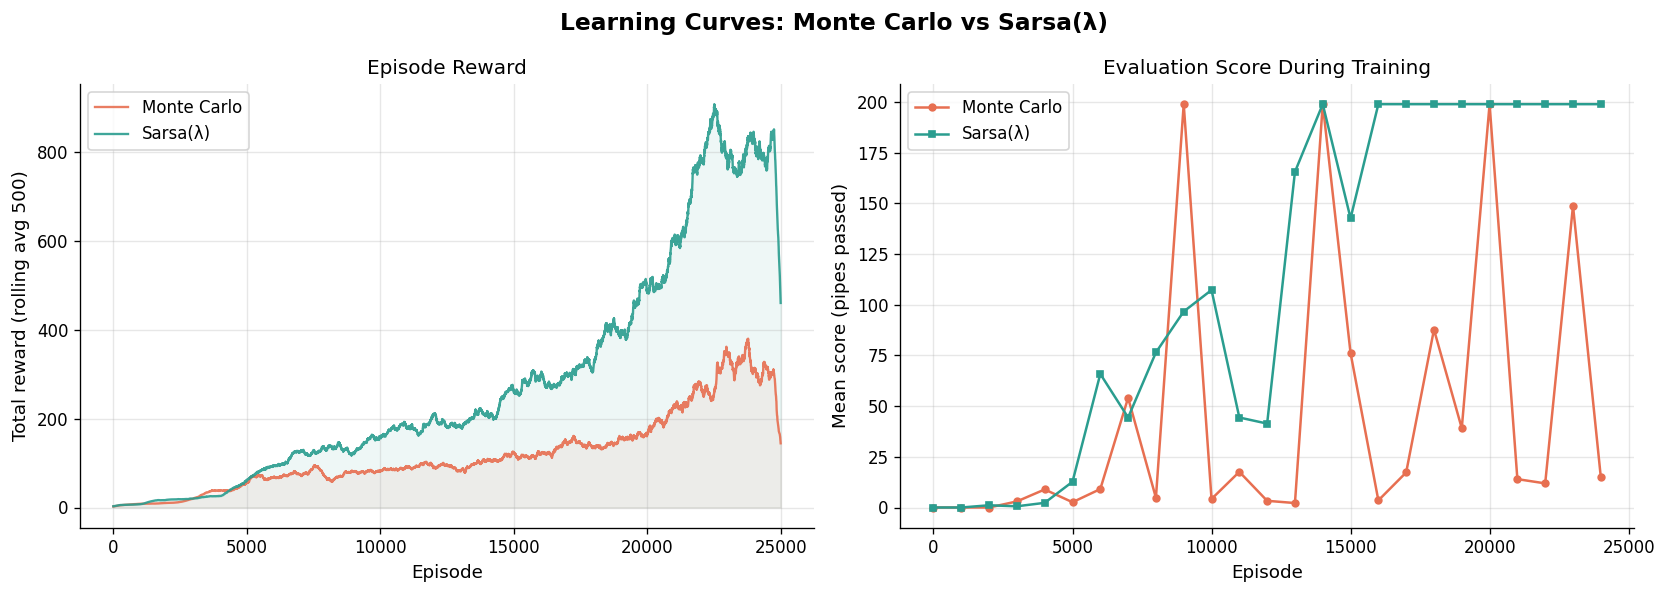

Figure saved: learning_curves.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves: Monte Carlo vs Sarsa(λ)', fontsize=14, fontweight='bold')

colors = {'mc': '#E76F51', 'sarsa': '#2A9D8F'}

# ── Left plot: rolling mean of episode reward ──────────────────────────────
ax = axes[0]
rm_mc    = rolling_mean(rewards_mc,    WINDOW)
rm_sarsa = rolling_mean(rewards_sarsa, WINDOW)
x = np.arange(N_EPISODES)

ax.plot(x, rm_mc,    color=colors['mc'],    lw=1.4, label='Monte Carlo', alpha=0.9)
ax.plot(x, rm_sarsa, color=colors['sarsa'], lw=1.4, label='Sarsa(λ)',     alpha=0.9)
ax.fill_between(x, 0, rm_mc,    color=colors['mc'],    alpha=0.08)
ax.fill_between(x, 0, rm_sarsa, color=colors['sarsa'], alpha=0.08)
ax.set_xlabel('Episode', fontsize=11)
ax.set_ylabel(f'Total reward (rolling avg {WINDOW})', fontsize=11)
ax.set_title('Episode Reward', fontsize=12)
ax.legend(fontsize=10)

# ── Right plot: score (pipes passed) over training ────────────────────────
ax = axes[1]
eps_mc,    scr_mc    = zip(*scores_mc)    if scores_mc    else ([], [])
eps_sarsa, scr_sarsa = zip(*scores_sarsa) if scores_sarsa else ([], [])

ax.plot(eps_mc,    scr_mc,    'o-', color=colors['mc'],    lw=1.5, ms=4, label='Monte Carlo')
ax.plot(eps_sarsa, scr_sarsa, 's-', color=colors['sarsa'], lw=1.5, ms=4, label='Sarsa(λ)')
ax.set_xlabel('Episode', fontsize=11)
ax.set_ylabel('Mean score (pipes passed)', fontsize=11)
ax.set_title('Evaluation Score During Training', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('learning_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: learning_curves.png')

---
## 7. State-Value Function Heatmaps

The **state-value function** V(S) = max_a Q(S, a) is plotted as a 2D heatmap with
- **x-axis:** horizontal distance to the upcoming pipe
- **y-axis:** vertical distance to the pipe gap centre (negative = above)

Bright regions = states perceived as high-value (good position); dark = bad.

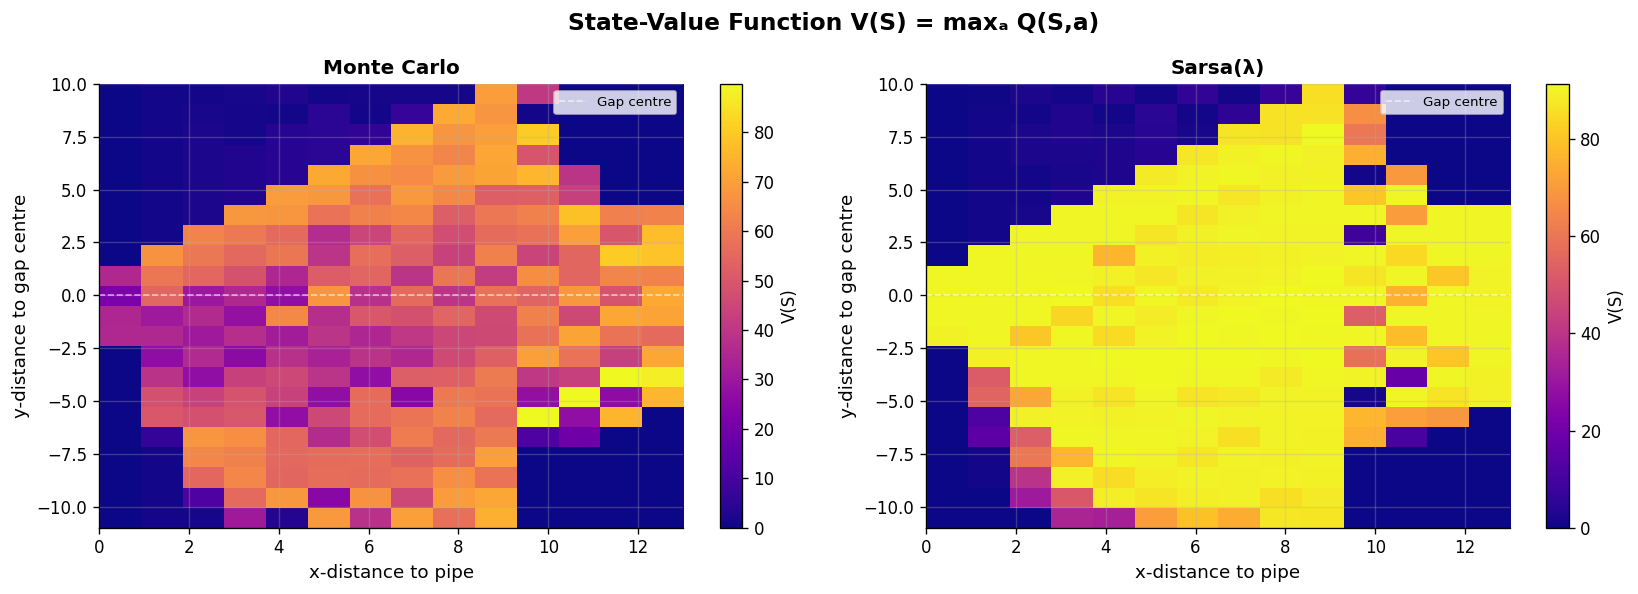

Figure saved: value_functions.png


In [10]:
def build_value_matrix(Q, env_config=None):
    """Build a 2D V-matrix from Q-table."""
    if env_config is None:
        env_config = ENV_CONFIG
    env_tmp = gym.make('TextFlappyBird-v0', max_episode_steps=2000, **env_config)
    x_n     = env_tmp.observation_space[0].n
    y_n     = env_tmp.observation_space[1].n
    y_start = env_tmp.observation_space[1].start
    env_tmp.close()

    V = np.zeros((x_n, y_n))
    for x in range(x_n):
        for yi, y in enumerate(range(y_start, y_start + y_n)):
            state = (x, y)
            if state in Q:
                V[x, yi] = np.max(Q[state])
    return V, x_n, y_n, y_start


def plot_value_heatmap(V, x_n, y_n, y_start, title, ax, cmap='viridis'):
    """Plot V as a 2D heatmap (x=horizontal dist, y=vertical dist)."""
    # V shape: (x_n, y_n) — transpose for display (y on vertical axis)
    im = ax.imshow(
        V.T,
        origin='lower',
        aspect='auto',
        cmap=cmap,
        extent=[0, x_n - 1, y_start, y_start + y_n - 1],
    )
    ax.set_xlabel('x-distance to pipe', fontsize=11)
    ax.set_ylabel('y-distance to gap centre', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.axhline(0, color='white', lw=1, linestyle='--', alpha=0.6, label='Gap centre')
    ax.legend(fontsize=8, loc='upper right')
    return im


V_mc,    x_n, y_n, y_start = build_value_matrix(Q_mc)
V_sarsa, *_                 = build_value_matrix(Q_sarsa)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('State-Value Function V(S) = maxₐ Q(S,a)', fontsize=14, fontweight='bold')

im1 = plot_value_heatmap(V_mc,    x_n, y_n, y_start, 'Monte Carlo',  axes[0], cmap='plasma')
im2 = plot_value_heatmap(V_sarsa, x_n, y_n, y_start, 'Sarsa(λ)',      axes[1], cmap='plasma')

fig.colorbar(im1, ax=axes[0], label='V(S)')
fig.colorbar(im2, ax=axes[1], label='V(S)')

plt.tight_layout()
plt.savefig('value_functions.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: value_functions.png')

---
## 8. Policy Visualisation

The learned policy π(S) = argmax_a Q(S, a) — which action does the agent choose in each state?

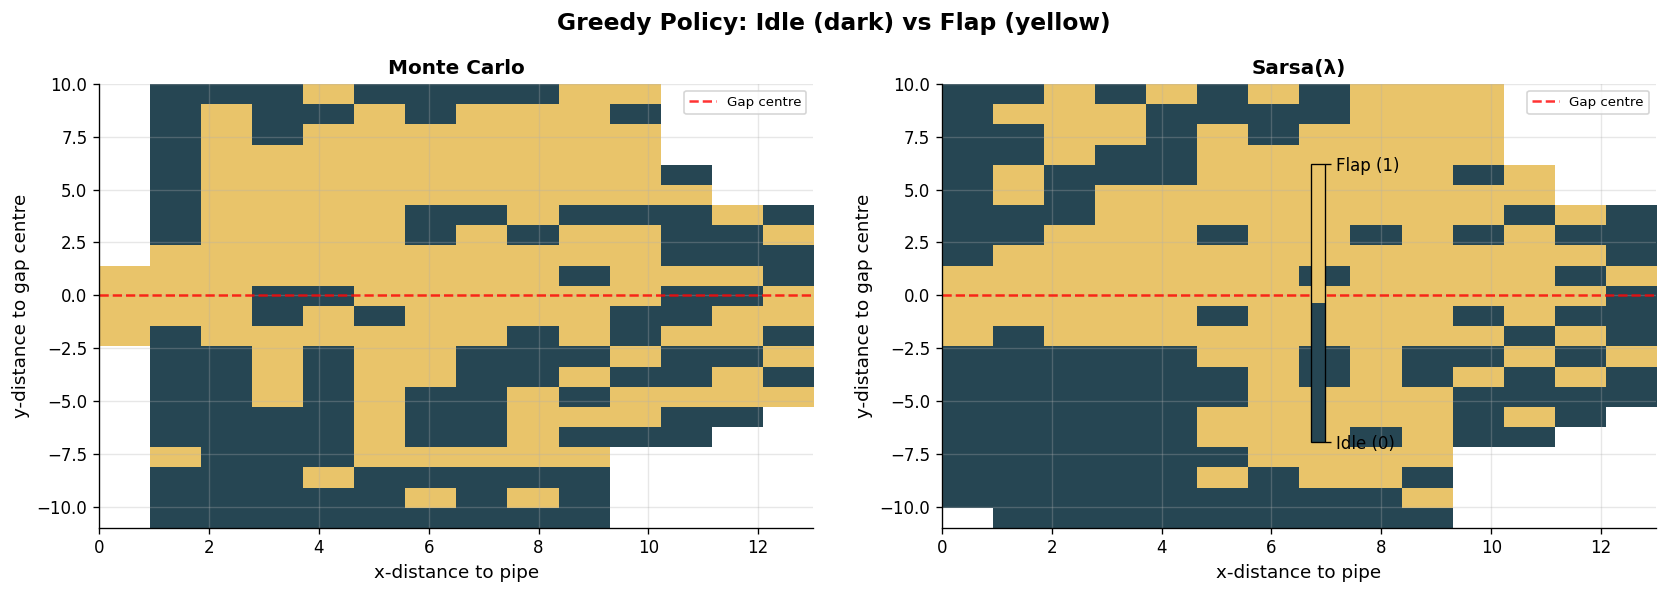

Figure saved: policies.png


In [11]:
def build_policy_matrix(Q, env_config=None):
    """Build a 2D policy matrix: 1=Flap, 0=Idle."""
    if env_config is None:
        env_config = ENV_CONFIG
    env_tmp = gym.make('TextFlappyBird-v0', max_episode_steps=2000, **env_config)
    x_n     = env_tmp.observation_space[0].n
    y_n     = env_tmp.observation_space[1].n
    y_start = env_tmp.observation_space[1].start
    env_tmp.close()

    P = np.full((x_n, y_n), np.nan)
    for x in range(x_n):
        for yi, y in enumerate(range(y_start, y_start + y_n)):
            state = (x, y)
            if state in Q:
                P[x, yi] = float(np.argmax(Q[state]))
    return P, x_n, y_n, y_start


P_mc,    *_ = build_policy_matrix(Q_mc)
P_sarsa, *_ = build_policy_matrix(Q_sarsa)

cmap_policy = mcolors.ListedColormap(['#264653', '#E9C46A'])  # dark=Idle, yellow=Flap

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Greedy Policy: Idle (dark) vs Flap (yellow)', fontsize=14, fontweight='bold')

for ax, P, name in zip(axes, [P_mc, P_sarsa], ['Monte Carlo', 'Sarsa(λ)']):
    im = ax.imshow(
        P.T, origin='lower', aspect='auto',
        cmap=cmap_policy, vmin=0, vmax=1,
        extent=[0, x_n - 1, y_start, y_start + y_n - 1],
    )
    ax.set_xlabel('x-distance to pipe', fontsize=11)
    ax.set_ylabel('y-distance to gap centre', fontsize=11)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.axhline(0, color='red', lw=1.5, linestyle='--', alpha=0.8, label='Gap centre')
    ax.legend(fontsize=8, loc='upper right')

cb = fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
cb.set_ticks([0, 1])
cb.set_ticklabels(['Idle (0)', 'Flap (1)'])

plt.tight_layout()
plt.savefig('policies.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: policies.png')

---
## 9. Parameter Sweep

We sweep over **α** (learning rate) and **λ** (trace decay for Sarsa) to study sensitivity.

In [12]:
# ── Parameter Sweep: α for both agents ─────────────────────────────────────
SWEEP_EPISODES = 10000  # fewer episodes for sweep
ALPHAS = [0.01, 0.05, 0.1, 0.2, 0.5]

results_sweep = {'alpha': ALPHAS, 'mc_score': [], 'mc_reward': [],
                 'sarsa_score': [], 'sarsa_reward': []}

print(f'Running α sweep over {ALPHAS} ({SWEEP_EPISODES:,} episodes each) …')

for a in tqdm(ALPHAS, desc='α sweep'):
    Qa_mc,    _, _ = train_monte_carlo(n_episodes=SWEEP_EPISODES, alpha=a, verbose=False)
    Qa_sarsa, _, _ = train_sarsa_lambda(n_episodes=SWEEP_EPISODES, alpha=a, verbose=False)

    sc_mc,  rw_mc  = eval_agent(Qa_mc,    n_eval=200)
    sc_sa,  rw_sa  = eval_agent(Qa_sarsa, n_eval=200)

    results_sweep['mc_score'].append(sc_mc)
    results_sweep['mc_reward'].append(rw_mc)
    results_sweep['sarsa_score'].append(sc_sa)
    results_sweep['sarsa_reward'].append(rw_sa)

df_sweep_alpha = pd.DataFrame(results_sweep)
print(df_sweep_alpha.to_string(index=False))

Running α sweep over [0.01, 0.05, 0.1, 0.2, 0.5] (10,000 episodes each) …


α sweep:   0%|          | 0/5 [00:00<?, ?it/s]

 alpha  mc_score  mc_reward  sarsa_score  sarsa_reward
  0.01     0.000       6.07        0.000         4.815
  0.05    25.335     263.77        0.825        16.240
  0.10   153.620    1544.32        5.470        64.300
  0.20     8.775      94.05      199.000      2000.000
  0.50    18.645     198.62       76.185       768.585


In [13]:
# ── Parameter Sweep: λ for Sarsa ───────────────────────────────────────────
LAMBDAS = [0.0, 0.3, 0.5, 0.7, 0.9, 0.99]

results_lam = {'lambda': LAMBDAS, 'sarsa_score': [], 'sarsa_reward': []}

print(f'Running λ sweep over {LAMBDAS} …')

for lam in tqdm(LAMBDAS, desc='λ sweep'):
    Ql, _, _ = train_sarsa_lambda(n_episodes=SWEEP_EPISODES, lam=lam, verbose=False)
    sc, rw   = eval_agent(Ql, n_eval=200)
    results_lam['sarsa_score'].append(sc)
    results_lam['sarsa_reward'].append(rw)

df_sweep_lam = pd.DataFrame(results_lam)
print(df_sweep_lam.to_string(index=False))

Running λ sweep over [0.0, 0.3, 0.5, 0.7, 0.9, 0.99] …


λ sweep:   0%|          | 0/6 [00:00<?, ?it/s]

 lambda  sarsa_score  sarsa_reward
   0.00        0.000        12.175
   0.30        2.210        30.400
   0.50        2.650        35.420
   0.70       16.615       173.680
   0.90       53.555       548.430
   0.99       30.985       320.535


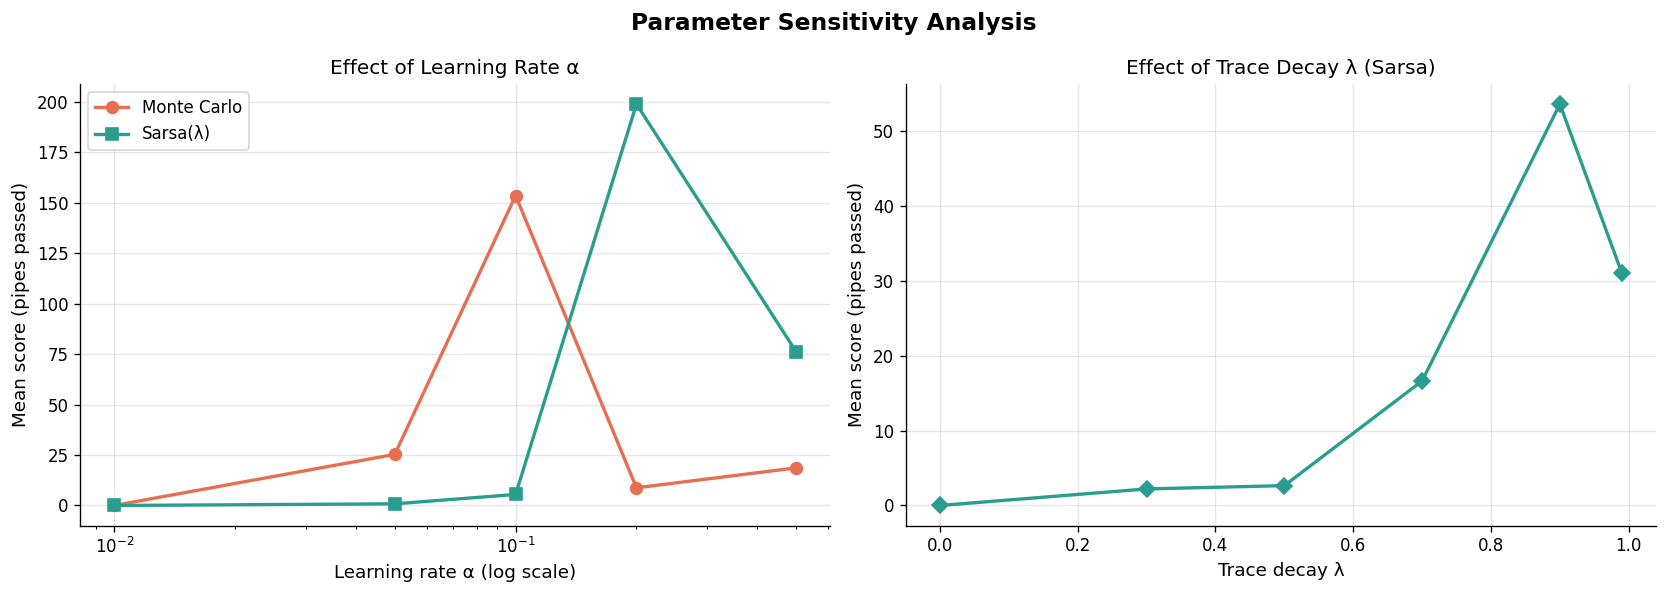

Figure saved: parameter_sweep.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Parameter Sensitivity Analysis', fontsize=14, fontweight='bold')

# ── α sweep ────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(df_sweep_alpha['alpha'], df_sweep_alpha['mc_score'],
        'o-', color=colors['mc'],    lw=2, ms=7, label='Monte Carlo')
ax.plot(df_sweep_alpha['alpha'], df_sweep_alpha['sarsa_score'],
        's-', color=colors['sarsa'], lw=2, ms=7, label='Sarsa(λ)')
ax.set_xscale('log')
ax.set_xlabel('Learning rate α (log scale)', fontsize=11)
ax.set_ylabel('Mean score (pipes passed)', fontsize=11)
ax.set_title('Effect of Learning Rate α', fontsize=12)
ax.legend(fontsize=10)

# ── λ sweep ────────────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(df_sweep_lam['lambda'], df_sweep_lam['sarsa_score'],
        'D-', color=colors['sarsa'], lw=2, ms=7)
ax.set_xlabel('Trace decay λ', fontsize=11)
ax.set_ylabel('Mean score (pipes passed)', fontsize=11)
ax.set_title('Effect of Trace Decay λ (Sarsa)', fontsize=12)

plt.tight_layout()
plt.savefig('parameter_sweep.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: parameter_sweep.png')

---
## 10. Question 4 — Generalisation to a New Configuration

We evaluate agents trained on the **default config** (height=15, width=20, pipe_gap=4) on a **different config** to assess generalisation.

In [15]:
ALT_CONFIG = dict(height=10, width=15, pipe_gap=3)  # smaller, harder world

# ── Evaluate pre-trained agents on the new config ──────────────────────────
sc_mc_alt,    rw_mc_alt    = eval_agent(Q_mc,    n_eval=500, env_config=ALT_CONFIG)
sc_sarsa_alt, rw_sarsa_alt = eval_agent(Q_sarsa, n_eval=500, env_config=ALT_CONFIG)

# ── Retrain agents from scratch on the new config ──────────────────────────
print('Retraining on alternative config …')
Q_mc_alt,    _, _ = train_monte_carlo( n_episodes=N_EPISODES, env_config=ALT_CONFIG, verbose=True)
Q_sarsa_alt, _, _ = train_sarsa_lambda(n_episodes=N_EPISODES, env_config=ALT_CONFIG, verbose=True)

sc_mc_alt_new,    rw_mc_alt_new    = eval_agent(Q_mc_alt,    n_eval=500, env_config=ALT_CONFIG)
sc_sarsa_alt_new, rw_sarsa_alt_new = eval_agent(Q_sarsa_alt, n_eval=500, env_config=ALT_CONFIG)

# ── Summary table ──────────────────────────────────────────────────────────
df_gen = pd.DataFrame({
    'Agent':       ['MC (default→alt)', 'Sarsa(λ) (default→alt)', 'MC (retrained)', 'Sarsa(λ) (retrained)'],
    'Mean Score':  [sc_mc_alt, sc_sarsa_alt, sc_mc_alt_new, sc_sarsa_alt_new],
    'Mean Reward': [rw_mc_alt, rw_sarsa_alt, rw_mc_alt_new, rw_sarsa_alt_new],
})
print('\nGeneralisation Results:')
print(df_gen.to_string(index=False))

Retraining on alternative config …


Monte Carlo:   0%|          | 0/25000 [00:00<?, ?ep/s]

Sarsa(λ):   0%|          | 0/25000 [00:00<?, ?ep/s]


Generalisation Results:
                 Agent  Mean Score  Mean Reward
      MC (default→alt)      12.040      106.320
Sarsa(λ) (default→alt)       1.704       23.632
        MC (retrained)       4.922       48.106
  Sarsa(λ) (retrained)     249.000     2000.000


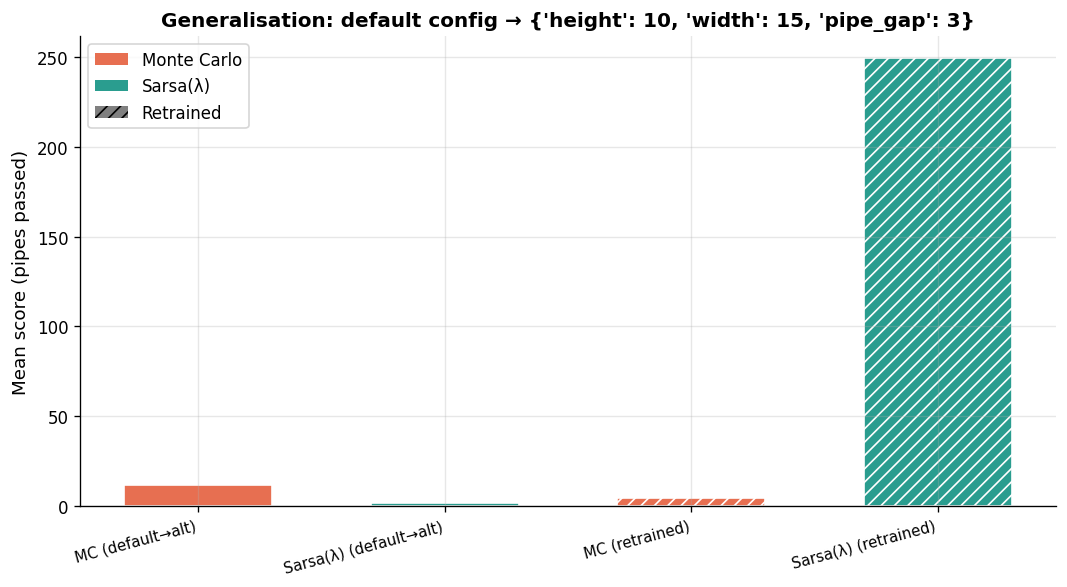

Figure saved: generalisation.png


In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(4)
bar_colors = [colors['mc'], colors['sarsa'], colors['mc'], colors['sarsa']]
hatches = ['', '', '///', '///']
labels = df_gen['Agent'].tolist()

bars = ax.bar(x_pos, df_gen['Mean Score'], color=bar_colors, edgecolor='white', width=0.6)
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Mean score (pipes passed)', fontsize=11)
ax.set_title(f'Generalisation: default config → {ALT_CONFIG}', fontsize=12, fontweight='bold')

# Add a legend patch
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor=colors['mc'],    label='Monte Carlo'),
    Patch(facecolor=colors['sarsa'], label='Sarsa(λ)'),
    Patch(facecolor='grey', hatch='///', label='Retrained'),
]
ax.legend(handles=legend_elems, fontsize=10)
plt.tight_layout()
plt.savefig('generalisation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: generalisation.png')

---
## 11. Summary & Discussion

### Q1 — Experimental Setup & Agent Differences

| Criterion | Monte Carlo | Sarsa(λ) |
|-----------|------------|----------|
| Update timing | End of episode | Every step |
| Bootstrapping | ❌ None |  TD error |
| Eligibility traces | ❌ |  λ-weighted |
| Convergence speed | Slow (high variance) | Fast |
| Parameter sensitivity | α | α, γ, λ |

### Q2 — TextFlappyBird-v0 vs TextFlappyBird-screen-v0

| | TextFlappyBird-v0 | TextFlappyBird-screen-v0 |
|---|---|---|
| Observation | (x, y) distances | Full screen render |
| State space | Small, discrete | Huge (curse of dimensionality) |
| Suitable for | Tabular RL | Deep RL (CNN) |

### Q3 — Original Flappy Bird
The original game uses continuous physics (velocity, gravity), larger screen, and pixel observations. Tabular MC/Sarsa cannot handle this directly — **Deep Q-Network (DQN)** with convolutional layers would be needed.

### Q4 — Generalisation
Tabular agents memorise (state, action) pairs. A new environment configuration changes the distribution of (x, y) states, causing the agent to encounter unseen states and fall back to default (zero) Q-values. **Retraining from scratch is necessary.**

### Q5 — Results Summary

In [17]:
df_final = pd.DataFrame({
    'Agent':        ['Monte Carlo', 'Sarsa(λ)'],
    'Mean Score':   [mean_score_mc, mean_score_sarsa],
    'Mean Reward':  [mean_reward_mc, mean_reward_sarsa],
    'States in Q':  [len(Q_mc), len(Q_sarsa)],
    'α':            [ALPHA, ALPHA],
    'γ':            [GAMMA, GAMMA],
    'ε (init)':     [EPSILON, EPSILON],
    'λ':            ['-', LAMBDA],
})
print('='*60)
print('   FINAL EVALUATION RESULTS (500 greedy episodes)')
print('='*60)
print(df_final.to_string(index=False))
print()

winner = 'Sarsa(λ)' if mean_score_sarsa >= mean_score_mc else 'Monte Carlo'
print(f'  Best agent: {winner}')

   FINAL EVALUATION RESULTS (500 greedy episodes)
      Agent  Mean Score  Mean Reward  States in Q   α    γ  ε (init)    λ
Monte Carlo      65.238       661.86          271 0.1 0.99       0.1    -
   Sarsa(λ)     199.000      2000.00          298 0.1 0.99       0.1  0.7

  Best agent: Sarsa(λ)


---
## 12. Rendered Demo (Greedy Policy)

Watch the best agent play!

In [18]:
def demo_agent(Q, name, n_steps=120, env_config=None):
    """Render a short episode with the greedy policy."""
    if env_config is None:
        env_config = ENV_CONFIG
    env_d = gym.make('TextFlappyBird-v0', max_episode_steps=2000, **env_config)
    state, info = env_d.reset(seed=SEED)
    print(f'\n Demo: {name}')
    print('-' * 40)

    total_reward = 0
    done = False
    step = 0
    while not done and step < n_steps:
        env_d.render()
        action = int(np.argmax(Q[state]))
        state, reward, terminated, truncated, info = env_d.step(action)
        done = terminated or truncated
        total_reward += reward
        step += 1

    env_d.close()
    print(f'  Score: {info["score"]} | Steps survived: {step}')


# Demonstrate the best agent
if mean_score_sarsa >= mean_score_mc:
    demo_agent(Q_sarsa, 'Sarsa(λ) — greedy policy')
else:
    demo_agent(Q_mc, 'Monte Carlo — greedy policy')


 Demo: Sarsa(λ) — greedy policy
----------------------------------------
  Score: 11 | Steps survived: 120
